# Workshop diagram — exploded data stack + building massing detail

Generates a two-panel diagram of the Pleiku UHI spatial analysis pipeline for workshop
teaching material:

- **Left panel** — six data layers exploded vertically as flat plates (bottom to top):
  1. Buildings footprint (Overture)
  2. Street network (OSM)
  3. Places (Overture)
  4. DEM terrain hillshade (NASADEM)
  5. NDVI vegetation index (Sentinel-2)
  6. UHI — land surface temperature (Landsat 9), the remote-sensing analysis layer
- **Right panel** — a detail panel: 3D building massing (footprints extruded to height,
  from the building-morphology model) for the densest sub-area of the ward, with a street
  underlay for orientation.

The approach (flat map layers stacked with vertical z-offsets, viewed from an isometric
camera) is adapted from the layer-explode step of VoxCity's demo-gif generator:
[`make_readme_demo_gif.py`](https://github.com/kunifujiwara/VoxCity/blob/main/scripts/make_readme_demo_gif.py).
VoxCity animates that explode as part of a rendered flythrough GIF; here it's simplified to
a single static `matplotlib` figure with two 3D subplots, saved as a PNG for slides.

**Run this notebook with the `gis` conda environment as the kernel** (`conda activate gis`) —
it needs `geopandas`, `rasterio`, `shapely`, `pyproj`, and `matplotlib`. On Windows, if you
instead run the equivalent script from a terminal, use `conda activate gis` first (or
`conda run -n gis python scripts/make_workshop_diagram.py`) rather than calling the env's
`python.exe` directly — without activation, the env's `Library/bin` DLLs (e.g. FreeType,
GDAL) aren't on `PATH` and `matplotlib` / `pyogrio` can fail to load correctly.

The full pipeline also lives as a standalone script at
[`scripts/make_workshop_diagram.py`](../scripts/make_workshop_diagram.py) — this notebook
walks through the same functions cell by cell so you can inspect and tweak each layer.


## 1. Imports & configuration

`Config` holds every path and style knob (colors, colormaps, vertical spacing, camera
angles) in one place. The three raster layers (DEM, NDVI, UHI) don't get their own
colorbar — their label text carries the clarifying source/units instead, to keep the
diagram uncluttered.


In [1]:
from __future__ import annotations

from dataclasses import dataclass, field
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pyproj
import rasterio
from mpl_toolkits.mplot3d import proj3d
from mpl_toolkits.mplot3d.art3d import Line3DCollection, Poly3DCollection
from rasterio.mask import mask as rio_mask

PROJECT_ROOT = Path.cwd().parents[1] if Path.cwd().name == "student" else (Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd())

# All vector/raster layers in the exploded stack are read into this CRS for plotting.
TARGET_CRS = "EPSG:4326"
# Used only to measure real-world (metric) site extent so the 3D boxes keep
# correct proportions even though the exploded-stack coordinates are lon/lat.
METRIC_CRS = "EPSG:32649"


In [2]:
@dataclass
class LayerStyle:
    label: str
    color: str = None
    alpha: float = 1.0
    cmap: str = None


@dataclass
class Config:
    boundary_path: Path = PROJECT_ROOT / "data/overture/phường_pleiku_boundary.gpkg"
    buildings_path: Path = PROJECT_ROOT / "data/overture/phường_pleiku_buildings.gpkg"
    streets_path: Path = PROJECT_ROOT / "data/osm/phường_pleiku_streets.gpkg"
    streets_layer: str = "edges"
    places_path: Path = PROJECT_ROOT / "data/overture/phường_pleiku_places.gpkg"
    dem_path: Path = PROJECT_ROOT / "data/dem/dtm_nasadem.tif"
    ndvi_path: Path = PROJECT_ROOT / "outputs/ndvi_2026.tif"
    lst_path: Path = (
        PROJECT_ROOT
        / "data/landsat/output/LC09_L2SP_124050_20260328_02_T1"
        / "temperature_lst_sharpened_reprojected.tif"
    )
    buildings_enriched_path: Path = PROJECT_ROOT / "data/gdf/phường_pleiku_buildings_enriched.gpkg"

    out_path: Path = PROJECT_ROOT / "outputs/workshop_diagram.png"

    # Vertical gap between exploded layers, as a fraction of the site's N-S extent.
    layer_gap_frac: float = 0.42

    elev: float = 30
    azim: float = -62
    figsize: tuple = (20, 13)
    dpi: int = 220

    # Building-massing detail panel: half-width (meters) of the sub-area box,
    # centered on the densest cluster of building footprints.
    massing_half_size: float = 300.0
    massing_elev: float = 38
    massing_azim: float = -55

    buildings: LayerStyle = field(default_factory=lambda: LayerStyle("Buildings footprint\n(Overture)", "#3a4a5c", 0.9))
    streets: LayerStyle = field(default_factory=lambda: LayerStyle("Street network\n(OSM)", "#e8823c", 1.0))
    places: LayerStyle = field(default_factory=lambda: LayerStyle("Places\n(Overture)", "#1f9d7c", 0.85))
    dem: LayerStyle = field(default_factory=lambda: LayerStyle(
        "DEM \u2014 terrain hillshade\n(NASADEM)", alpha=0.95, cmap="gray"
    ))
    ndvi: LayerStyle = field(default_factory=lambda: LayerStyle(
        "NDVI \u2014 vegetation index\n(Sentinel-2, 2026)", alpha=0.95, cmap="RdYlGn"
    ))
    uhi: LayerStyle = field(default_factory=lambda: LayerStyle(
        "UHI \u2014 land surface temperature\n(Landsat 9, remote sensing)", alpha=0.95, cmap="inferno"
    ))


cfg = Config()
cfg


Config(boundary_path=WindowsPath('C:/Users/Maddie/OneDrive/000_CIC2025/CIC2025/100 Lab Notes/Projects/CIC2025 Masterthesis/Experiments/data/overture/phường_pleiku_boundary.gpkg'), buildings_path=WindowsPath('C:/Users/Maddie/OneDrive/000_CIC2025/CIC2025/100 Lab Notes/Projects/CIC2025 Masterthesis/Experiments/data/overture/phường_pleiku_buildings.gpkg'), streets_path=WindowsPath('C:/Users/Maddie/OneDrive/000_CIC2025/CIC2025/100 Lab Notes/Projects/CIC2025 Masterthesis/Experiments/data/osm/phường_pleiku_streets.gpkg'), streets_layer='edges', places_path=WindowsPath('C:/Users/Maddie/OneDrive/000_CIC2025/CIC2025/100 Lab Notes/Projects/CIC2025 Masterthesis/Experiments/data/overture/phường_pleiku_places.gpkg'), dem_path=WindowsPath('C:/Users/Maddie/OneDrive/000_CIC2025/CIC2025/100 Lab Notes/Projects/CIC2025 Masterthesis/Experiments/data/dem/dtm_nasadem.tif'), ndvi_path=WindowsPath('C:/Users/Maddie/OneDrive/000_CIC2025/CIC2025/100 Lab Notes/Projects/CIC2025 Masterthesis/Experiments/outputs/ndvi

## 2. Load each layer

Vector loaders reproject to `TARGET_CRS` and clip to the ward boundary. `load_raster` is
generic across all three rasters: it crops with `rasterio.mask`, builds a pixel-center
coordinate grid in the raster's *own* CRS, and — this is the part worth noting — transforms
that grid into `TARGET_CRS` with `pyproj` when the raster's native CRS differs (the NDVI
tif here is in UTM 49N, while DEM and LST are already lon/lat). Without that step the NDVI
plate would be plotted in the wrong coordinate system and not line up with the other layers.

`hillshade` turns the raw DEM elevation into a shaded-relief array (standard
azimuth/altitude lighting model) — far more legible as a flat plate than a flat color ramp
over elevation values.


In [3]:
def load_boundary(cfg: Config) -> gpd.GeoDataFrame:
    return gpd.read_file(cfg.boundary_path).to_crs(TARGET_CRS)


def load_buildings(cfg: Config, boundary: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    gdf = gpd.read_file(cfg.buildings_path).to_crs(TARGET_CRS)
    return gpd.clip(gdf, boundary)


def load_streets(cfg: Config, boundary: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    gdf = gpd.read_file(cfg.streets_path, layer=cfg.streets_layer).to_crs(TARGET_CRS)
    return gpd.clip(gdf, boundary)


def load_places(cfg: Config, boundary: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    gdf = gpd.read_file(cfg.places_path).to_crs(TARGET_CRS)
    return gpd.clip(gdf, boundary)


def load_raster(path: Path, boundary: gpd.GeoDataFrame, target_crs: str = TARGET_CRS):
    """Read a raster cropped to the boundary and return an (X, Y, Z) grid in target_crs.

    Works for rasters in any source CRS: the pixel-center coordinate grid is
    built in the raster's native CRS, then transformed into target_crs so every
    layer -- vector or raster -- can be plotted on the same axes.
    """
    with rasterio.open(path) as src:
        geom = [boundary.to_crs(src.crs).geometry.union_all()]
        fill = src.nodata if src.nodata is not None else 0
        arr, transform = rio_mask(src, geom, crop=True, nodata=fill, filled=True)
        arr = arr[0].astype("float64")
        arr[arr == fill] = np.nan
        src_crs = src.crs

    h, w = arr.shape
    xs = transform.c + transform.a * (np.arange(w) + 0.5)
    ys = transform.f + transform.e * (np.arange(h) + 0.5)
    x, y = np.meshgrid(xs, ys)

    if str(src_crs) != target_crs:
        transformer = pyproj.Transformer.from_crs(src_crs, target_crs, always_xy=True)
        x, y = transformer.transform(x, y)

    return x, y, arr


def hillshade(elevation: np.ndarray, cellsize: float = 30.0, azimuth: float = 315.0, altitude: float = 45.0) -> np.ndarray:
    """Standard analytical hillshade from an elevation grid."""
    az_rad = np.radians(360.0 - azimuth + 90.0)
    alt_rad = np.radians(altitude)
    dy, dx = np.gradient(elevation, cellsize)
    slope = np.pi / 2.0 - np.arctan(np.hypot(dx, dy))
    aspect = np.arctan2(-dx, dy)
    shaded = np.sin(alt_rad) * np.sin(slope) + np.cos(alt_rad) * np.cos(slope) * np.cos(az_rad - aspect)
    return np.clip(shaded, 0, 1)


def site_extent_m(boundary: gpd.GeoDataFrame) -> tuple:
    """Real-world width/height of the site in meters, used for the 3D box aspect."""
    minx, miny, maxx, maxy = boundary.to_crs(METRIC_CRS).total_bounds
    return maxx - minx, maxy - miny


In [4]:
boundary = load_boundary(cfg)
buildings = load_buildings(cfg, boundary)
streets = load_streets(cfg, boundary)
places = load_places(cfg, boundary)
dem_x, dem_y, dem_z = load_raster(cfg.dem_path, boundary)
ndvi_x, ndvi_y, ndvi_z = load_raster(cfg.ndvi_path, boundary)
lst_x, lst_y, lst_z = load_raster(cfg.lst_path, boundary)

print(f"boundary bounds: {boundary.total_bounds}")
print(f"buildings: {len(buildings)} footprints, streets: {len(streets)} edges, places: {len(places)} points")
print(f"DEM grid: {dem_z.shape}, NDVI grid: {ndvi_z.shape}, LST grid: {lst_z.shape}")


boundary bounds: [107.9950633  13.9656066 108.0633816  14.0336306]
buildings: 21287 footprints, streets: 3291 edges, places: 3380 points
DEM grid: (245, 246), NDVI grid: (750, 741), LST grid: (745, 749)


## 3. Layer-plotting helpers

Each helper draws one layer type onto a shared 3D axis at a fixed height `z`:

- **`add_polygon_layer`** — building footprints (Overture)
- **`add_line_layer`** — street centerlines (OSM), reused later for the massing panel's
  street underlay
- **`add_point_layer`** — places (Overture), plotted as a flat scatter at height `z`
- **`add_raster_layer`** — DEM / NDVI / UHI grids as `contourf` plates projected onto the
  `z` plane (`zdir="z", offset=z`)

`add_plate_frame` draws the ward outline on a layer's plate — per the requested look, this
is only called for the street, DEM, NDVI and UHI layers, **not** for buildings or places,
which are dense enough that an outline is just clutter. `add_vertical_connectors` draws the
dashed corner lines linking every level regardless, which is what reads as an "exploded"
stack. `add_layer_label` projects each layer's label to screen space explicitly (see the
note in its docstring) rather than relying on 3D text placement, which the original 3-layer
version showed can visually collide with a neighboring plate on an elongated footprint like
this ward.


In [5]:
def add_polygon_layer(ax, gdf: gpd.GeoDataFrame, z: float, color: str, alpha: float) -> None:
    polys = []
    for geom in gdf.geometry:
        if geom is None or geom.is_empty:
            continue
        parts = geom.geoms if geom.geom_type == "MultiPolygon" else [geom]
        for part in parts:
            xy = np.asarray(part.exterior.coords)
            polys.append(np.column_stack([xy, np.full(len(xy), z)]))
    ax.add_collection3d(
        Poly3DCollection(polys, facecolor=color, edgecolor="none", alpha=alpha),
        autolim=False,
    )


def add_line_layer(ax, gdf: gpd.GeoDataFrame, z: float, color: str, linewidth: float = 0.7, alpha: float = 1.0) -> None:
    segments = []
    for geom in gdf.geometry:
        if geom is None or geom.is_empty:
            continue
        parts = geom.geoms if geom.geom_type == "MultiLineString" else [geom]
        for part in parts:
            xy = np.asarray(part.coords)
            segments.append(np.column_stack([xy, np.full(len(xy), z)]))
    ax.add_collection3d(
        Line3DCollection(segments, colors=color, linewidths=linewidth, alpha=alpha),
        autolim=False,
    )


def add_point_layer(ax, gdf: gpd.GeoDataFrame, z: float, color: str, size: float = 5.0, alpha: float = 0.85) -> None:
    pts = gdf.geometry.representative_point()
    xs, ys = pts.x.to_numpy(), pts.y.to_numpy()
    ax.scatter(xs, ys, zs=z, zdir="z", s=size, color=color, alpha=alpha, depthshade=False, linewidths=0)


def add_raster_layer(ax, x, y, arr, z: float, cmap: str, levels: int = 30, alpha: float = 0.95):
    vmin, vmax = np.nanpercentile(arr, [2, 98])
    return ax.contourf(
        x, y, arr, zdir="z", offset=z,
        levels=np.linspace(vmin, vmax, levels),
        cmap=cmap, alpha=alpha, vmin=vmin, vmax=vmax,
    )


def plate_corners(boundary: gpd.GeoDataFrame) -> np.ndarray:
    minx, miny, maxx, maxy = boundary.total_bounds
    return np.array([[minx, miny], [maxx, miny], [maxx, maxy], [minx, maxy]])


def add_plate_frame(ax, boundary: gpd.GeoDataFrame, z: float, color: str = "black", linewidth: float = 0.8) -> None:
    ring = np.asarray(boundary.geometry.iloc[0].exterior.coords)
    ax.plot(ring[:, 0], ring[:, 1], zs=z, zdir="z", color=color, linewidth=linewidth, alpha=0.6)


def add_vertical_connectors(ax, corners: np.ndarray, z_levels: list, color: str = "gray") -> None:
    for cx, cy in corners:
        ax.plot(
            [cx, cx], [cy, cy], [min(z_levels), max(z_levels)],
            color=color, linewidth=0.6, linestyle=(0, (3, 3)), alpha=0.35,
        )


def add_layer_label(fig, ax, boundary: gpd.GeoDataFrame, z: float, text: str) -> None:
    """Place a label at the screen position corresponding to 3D point (x, y, z).

    Drawn with `fig.text` (figure space, not axes/data space) so it always
    renders on top of every plate -- a plain `ax.text(x, y, z, ...)` call can
    end up visually behind or crowded against a neighboring plate once the
    3D-to-2D projection is applied to a very elongated footprint like this one.
    """
    minx, miny, maxx, maxy = boundary.total_bounds
    x = maxx + (maxx - minx) * 0.05
    y = miny + (maxy - miny) * 0.5
    x2, y2, _ = proj3d.proj_transform(x, y, z, ax.get_proj())
    disp = ax.transData.transform((x2, y2))
    fx, fy = fig.transFigure.inverted().transform(disp)
    fig.text(fx, fy, text, fontsize=9.5, va="center", ha="left", fontweight="medium")


## 4. Left panel — assemble the exploded stack

Six layers stacked at `z = 0, gap, 2*gap, ..., 5*gap`, where `gap` is a fraction of the
site's north–south extent (`layer_gap_frac`). `ax.set_box_aspect` uses the *metric* extent
so the plates keep correct proportions even though the plotted coordinates are lon/lat.


In [6]:
def build_stack_panel(fig, ax, cfg: Config) -> None:
    boundary = load_boundary(cfg)
    buildings = load_buildings(cfg, boundary)
    streets = load_streets(cfg, boundary)
    places = load_places(cfg, boundary)
    dem_x, dem_y, dem_z = load_raster(cfg.dem_path, boundary)
    ndvi_x, ndvi_y, ndvi_z = load_raster(cfg.ndvi_path, boundary)
    lst_x, lst_y, lst_z = load_raster(cfg.lst_path, boundary)

    dx, dy = site_extent_m(boundary)
    gap = dy * cfg.layer_gap_frac
    n_layers = 6
    z_levels = [i * gap for i in range(n_layers)]
    z_buildings, z_streets, z_places, z_dem, z_ndvi, z_uhi = z_levels

    ax.set_box_aspect((dx, dy, (n_layers - 1) * gap * 1.15))

    add_polygon_layer(ax, buildings, z_buildings, cfg.buildings.color, cfg.buildings.alpha)
    add_line_layer(ax, streets, z_streets, cfg.streets.color)
    add_point_layer(ax, places, z_places, cfg.places.color)
    add_raster_layer(ax, dem_x, dem_y, hillshade(dem_z), z_dem, cmap=cfg.dem.cmap, alpha=cfg.dem.alpha)
    add_raster_layer(ax, ndvi_x, ndvi_y, ndvi_z, z_ndvi, cmap=cfg.ndvi.cmap, alpha=cfg.ndvi.alpha)
    add_raster_layer(ax, lst_x, lst_y, lst_z, z_uhi, cmap=cfg.uhi.cmap, alpha=cfg.uhi.alpha)

    # Boundary frame on every layer except buildings/places, per the requested look.
    for z in (z_streets, z_dem, z_ndvi, z_uhi):
        add_plate_frame(ax, boundary, z)
    add_vertical_connectors(ax, plate_corners(boundary), z_levels)

    add_layer_label(fig, ax, boundary, z_buildings, cfg.buildings.label)
    add_layer_label(fig, ax, boundary, z_streets, cfg.streets.label)
    add_layer_label(fig, ax, boundary, z_places, cfg.places.label)
    add_layer_label(fig, ax, boundary, z_dem, cfg.dem.label)
    add_layer_label(fig, ax, boundary, z_ndvi, cfg.ndvi.label)
    add_layer_label(fig, ax, boundary, z_uhi, cfg.uhi.label)

    minx, miny, maxx, maxy = boundary.total_bounds
    ax.set_xlim(minx, maxx)
    ax.set_ylim(miny, maxy)
    ax.set_zlim(z_buildings - gap * 0.2, z_uhi + gap * 0.35)
    ax.set_axis_off()
    ax.view_init(elev=cfg.elev, azim=cfg.azim)
    ax.set_title("Data stack", fontsize=12, fontweight="bold", pad=0)


## 5. Right panel — 3D building massing detail

A full-ward extrusion of all ~21k buildings would be heavy and unreadable at this scale, so
`densest_subarea` finds the densest cluster of building footprints (a coarse 2D histogram
of centroids) and crops to a square box around it — a much more legible "detail" view than
the whole elongated ward. Heights come from the building-morphology model's `height_est`
column (Overture's own `height` field is empty for this dataset). Each building becomes a
set of wall quads plus a roof polygon.


In [7]:
def load_enriched_buildings(cfg: Config) -> gpd.GeoDataFrame:
    gdf = gpd.read_file(cfg.buildings_enriched_path)
    height = gdf["height"].fillna(gdf["height_est"])
    height = height.fillna(height.median()).clip(lower=3.0)
    gdf = gdf.assign(height_m=height)
    return gdf


def densest_subarea(gdf: gpd.GeoDataFrame, half_size: float, bins: int = 40):
    """Find the densest cluster of building footprints and return a square box (in gdf's CRS)."""
    centroids = gdf.geometry.centroid
    xs, ys = centroids.x.to_numpy(), centroids.y.to_numpy()
    counts, xedges, yedges = np.histogram2d(xs, ys, bins=bins)
    iy, ix = np.unravel_index(np.argmax(counts), counts.shape)
    cx = (xedges[iy] + xedges[iy + 1]) / 2
    cy = (yedges[ix] + yedges[ix + 1]) / 2
    from shapely.geometry import box
    return box(cx - half_size, cy - half_size, cx + half_size, cy + half_size)


def add_extruded_buildings(ax, gdf: gpd.GeoDataFrame, facecolor: str = "#e4e7eb", edgecolor: str = "#7b8794") -> None:
    walls, roofs = [], []
    for geom, h in zip(gdf.geometry, gdf["height_m"]):
        if geom is None or geom.is_empty:
            continue
        parts = geom.geoms if geom.geom_type == "MultiPolygon" else [geom]
        for part in parts:
            xy = np.asarray(part.exterior.coords)
            roofs.append(np.column_stack([xy, np.full(len(xy), h)]))
            for (x0, y0), (x1, y1) in zip(xy[:-1], xy[1:]):
                walls.append([(x0, y0, 0), (x1, y1, 0), (x1, y1, h), (x0, y0, h)])

    ax.add_collection3d(
        Poly3DCollection(walls, facecolor=facecolor, edgecolor=edgecolor, linewidths=0.25, alpha=1.0),
        autolim=False,
    )
    ax.add_collection3d(
        Poly3DCollection(roofs, facecolor="#c6cbd1", edgecolor=edgecolor, linewidths=0.25, alpha=1.0),
        autolim=False,
    )


def build_massing_panel(ax, cfg: Config) -> None:
    enriched = load_enriched_buildings(cfg)
    site_box = densest_subarea(enriched, cfg.massing_half_size)
    site_gdf = gpd.GeoDataFrame(geometry=[site_box], crs=enriched.crs)

    buildings = gpd.clip(enriched, site_gdf)
    streets = gpd.read_file(cfg.streets_path, layer=cfg.streets_layer)
    streets = gpd.clip(streets.to_crs(enriched.crs), site_gdf)

    minx, miny, maxx, maxy = site_box.bounds
    add_line_layer(ax, streets, 0.02, "#c2c9d1", linewidth=1.0, alpha=0.9)
    add_extruded_buildings(ax, buildings)

    ax.set_box_aspect((maxx - minx, maxy - miny, buildings["height_m"].max() * 1.6))
    ax.set_xlim(minx, maxx)
    ax.set_ylim(miny, maxy)
    ax.set_zlim(0, buildings["height_m"].max() * 1.6)
    ax.set_axis_off()
    ax.view_init(elev=cfg.massing_elev, azim=cfg.massing_azim)
    ax.set_title(
        "Building massing \u2014 detail\n(heights from morphology model, densest cluster)",
        fontsize=12, fontweight="bold", pad=0,
    )


## 6. Assemble the full figure and render

`GridSpec` places the exploded stack (wider) beside the massing detail panel. Run this cell
to build the diagram inline; adjust `cfg.elev`/`cfg.azim` (stack) or `cfg.massing_elev`/
`cfg.massing_azim` (massing) and re-run to change either camera angle.


Saved diagram to C:\Users\Maddie\OneDrive\000_CIC2025\CIC2025\100 Lab Notes\Projects\CIC2025 Masterthesis\Experiments\outputs\workshop_diagram.png


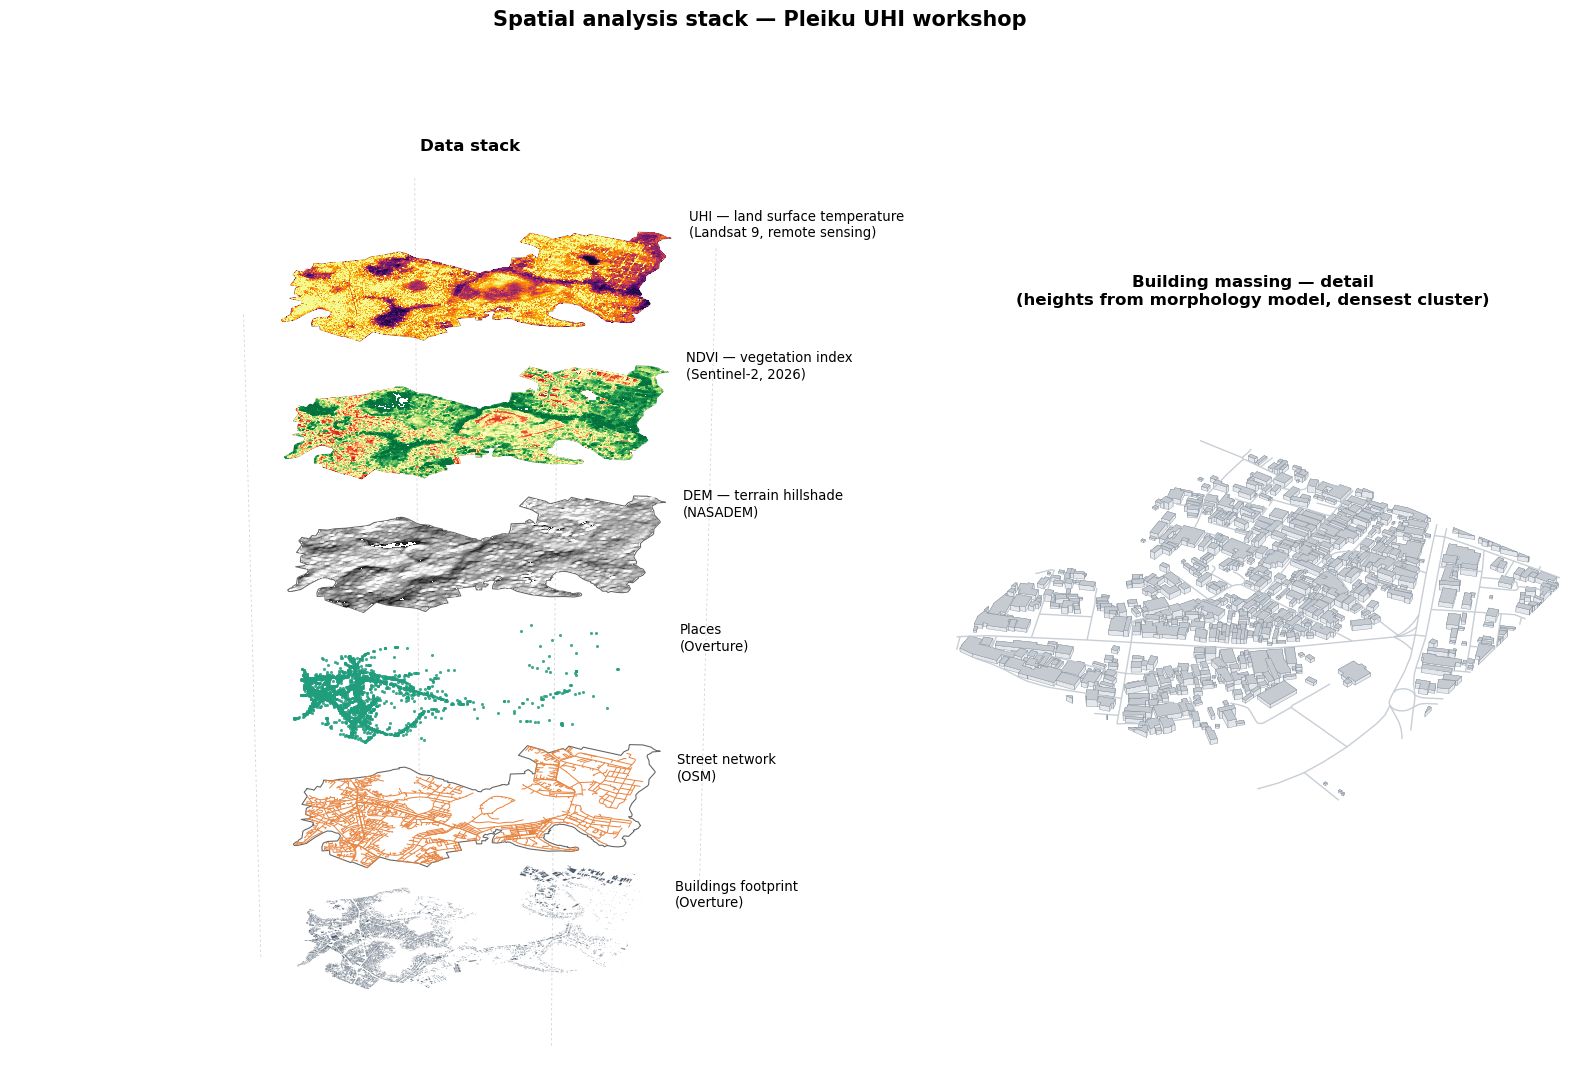

In [8]:
def build_figure(cfg: Config):
    fig = plt.figure(figsize=cfg.figsize)
    gs = fig.add_gridspec(1, 2, width_ratios=(1.5, 1), wspace=0.02)
    ax_stack = fig.add_subplot(gs[0, 0], projection="3d")
    ax_massing = fig.add_subplot(gs[0, 1], projection="3d")

    build_stack_panel(fig, ax_stack, cfg)
    build_massing_panel(ax_massing, cfg)

    fig.suptitle(
        "Spatial analysis stack \u2014 Pleiku UHI workshop",
        fontsize=15, fontweight="bold", y=0.96,
    )
    return fig, (ax_stack, ax_massing)


fig, (ax_stack, ax_massing) = build_figure(cfg)
cfg.out_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(cfg.out_path, dpi=cfg.dpi, bbox_inches="tight", facecolor="white")
print(f"Saved diagram to {cfg.out_path}")
plt.show()


## 7. Variations to try

- **Stack camera angle** — set `cfg.elev` / `cfg.azim` and re-run cell 6.
- **Massing camera angle / crop size** — `cfg.massing_elev` / `cfg.massing_azim` for the
  angle, `cfg.massing_half_size` for how large a sub-area to extrude (larger = more context,
  slower to render and more visually busy).
- **Layer spacing** — increase `cfg.layer_gap_frac` to pull the plates further apart.
- **Different raster products** — swap `cfg.ndvi_path` / `cfg.lst_path` for another date
  (e.g. `outputs/ndvi_2017.tif`, or the 2026-04-29 Landsat acquisition under
  `data/landsat/output/`) to show change over time instead.
- **Command-line use** — the same logic is packaged as
  [`scripts/make_workshop_diagram.py`](../scripts/make_workshop_diagram.py), runnable as:
  ```bash
  conda activate gis
  python scripts/make_workshop_diagram.py --out outputs/workshop_diagram.png --elev 25 --azim -50
  ```
